<a href="https://colab.research.google.com/github/saraduquej/Analitica-de-negocios/blob/main/Reto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio**
El avance de la analítica de datos en el sector salud ha permitido desarrollar herramientas que apoyan la detección temprana de enfermedades cardiovasculares, una de las principales causas de mortalidad a nivel mundial. Identificar oportunamente a los pacientes con mayor probabilidad de presentar esta condición permite implementar estrategias preventivas y tratamientos adecuados antes de que ocurran complicaciones graves.


En este caso de estudio, se implementa un modelo de árbol de decisión con el fin de clasificar a los pacientes según presenten o no enfermedad cardíaca. A partir de variables clínicas, el modelo busca encontrar patrones que permitan predecir el estado de salud cardiovascular y así contribuir a una toma de decisiones médicas basadas en datos.

**Variables del análisis:**
- **Age:** edad del paciente. El riesgo de enfermedades cardiovasculares tiende a aumentar con la edad debido al desgaste progresivo del sistema circulatorio y la mayor exposición a factores de riesgo.

- **Systolic:** presión arterial sistólica, que mide la presión en las arterias cuando el corazón se contrae. Valores elevados pueden estar asociados a hipertensión, uno de los principales factores de riesgo cardiovascular.

- **Diastolic:** presión arterial diastólica, que mide la presión en las arterias cuando el corazón está en reposo entre latidos. Complementa la información de la presión sistólica para evaluar la salud arterial.

- **BMI:** índice de Masa Corporal (IMC), indicador que relaciona peso y estatura. Un IMC elevado puede asociarse con sobrepeso u obesidad, condiciones que incrementan la probabilidad de desarrollar enfermedades cardíacas.

En conjunto, estas variables permiten analizar cómo factores demográficos y clínicos influyen en la probabilidad de padecer una enfermedad cardiovascular.

**0. Carga de las librerias de trabajo**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_text

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Carga de los datos de trabajo**

In [ ]:
nxl = '/content/drive/MyDrive/Analítica de negocios/2. HeartDisease.xlsx'
XDB = pd.read_excel(nxl,sheet_name=0)

#Llamamos los datos de entrada "XD"
XD = XDB.iloc[:, [1,2,3,4]]

#Llamamos los datos de salida "yd"
yd = XDB.iloc[:, 0]

**2. Se procede con la implementación del modelo de árbol**

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)

#¿y que fue lo que hizo el modelo?
ydp = mar.predict(XD)

#Se construye la matriz de confusión
cm = confusion_matrix(yd,ydp)
VN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
VP = cm[1,1]

display (cm)

#Métricas de desempeño
Ex = (VP+VN)/len(XD)  #1.Exactitud: comportamiento general
print("La exactitud es:",Ex)

Sen = VP/(VP+FN)  #2.Sensibilidad: capacidad de detectar casos positivos
print("La sensibilidad es:",Sen)

Spe = VN/(VN+FP)  #3.Especificidad: capacidad de detectar casos negativos
print("La especificidad es:",Spe)

Pre = VP/(VP+FP)  #4.Precisión: capacidad de identificar casos positivos
print("La precisión es:",Pre)

PreNeg = VN/(VN+FN)   #5.Predicción Negativa: como se comporta pronosticando negativos
print("La predicción negativa es:",PreNeg)

array([[63, 10],
       [20, 87]])

La exactitud es: 0.8333333333333334
La sensibilidad es: 0.8130841121495327
La especificidad es: 0.863013698630137
La precisión es: 0.8969072164948454
La predicción negativa es: 0.7590361445783133


##**Análisis de resultados**
El modelo muestra un desempeño bastante bueno en términos generales, con una exactitud del 83%, lo que significa que clasifica correctamente el 83% de todos los pacientes. La precisión es alta (casi 90%), lo que indica que cuando el modelo predice enfermedad cardíaca, en la mayoría de los casos esa predicción es correcta. Además, la especificidad del 86% refleja que el modelo identifica adecuadamente a los pacientes sanos, es decir, tiene una buena capacidad para reconocer verdaderos negativos y evitar falsas alarmas.

Por otro lado, la sensibilidad del 81% indica que el modelo detecta correctamente a la mayoría de los pacientes que realmente tienen la enfermedad, lo cual es un aspecto clave en contextos clínicos. La predicción negativa del 76% indica que cuando el modelo dice que un paciente está sano, existe todavía un margen considerable de error. En un entorno clínico esto es relevante, porque implica que algunos pacientes podrían recibir una falsa sensación de seguridad, por lo que sería importante mejorar este aspecto del modelo y reducir ese número para que el sistema sea aún más confiable como herramienta de apoyo clínico.


**3. Se hace la predicción con la hoja 2**

In [ ]:
XDB = pd.read_excel(nxl,sheet_name=1)

XD2 = XDB.iloc[:, [1,2,3,4]]

ydp = mar.predict(XD2)

display (XD2)
display(ydp)

,Age,Systolic,Diastolic,BMI
0,33,120,64,33
1,55,115,81,32
2,51,130,70,20
3,65,101,63,18
4,62,109,110,38
5,60,130,69,35
6,61,124,95,36
7,53,150,81,41


array([0, 0, 0, 1, 1, 1, 1, 1])

##**Análisis de resultados**
Cuando se aplicó el modelo a los 8 pacientes nuevos de la hoja 2 del documento de excel, las predicciones fueron: [0, 0, 0, 1, 1, 1, 1, 1]. Esto quiere decir que de 8 pacientes, 3 fueron clasificados como sanos y 5 con enfermedad cardíaca.

En general, el modelo toma decisiones coherentes con los factores clínicos: cuando detecta combinaciones de mayor edad, presión arterial más alta o BMI elevado, tiende a clasificar como positivo. Esto muestra que el modelo aplica reglas lógicas basadas en los patrones que aprendió y que puede utilizar esa información para evaluar pacientes nuevos de forma consistente.

**4. Despliegue del árbol de decisión**

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

vs = ["Age" , "Systolic" , "Diastolic" , "BMI"]
dot_data = export_graphviz(mar,feature_names=vs)
graph = graph_from_dot_data(dot_data)
graph.write_png('Arbol.png')

True

**5. Despliegue de los nodos del árbol**

In [ ]:
tree_rules = export_text(mar,feature_names=vs)
print(tree_rules)

|--- Age <= 54.50
|   |--- BMI <= 34.50
|   |   |--- Systolic <= 115.50
|   |   |   |--- BMI <= 20.50
|   |   |   |   |--- class: 0
|   |   |   |--- BMI >  20.50
|   |   |   |   |--- class: 1
|   |   |--- Systolic >  115.50
|   |   |   |--- Diastolic <= 60.50
|   |   |   |   |--- class: 1
|   |   |   |--- Diastolic >  60.50
|   |   |   |   |--- class: 0
|   |--- BMI >  34.50
|   |   |--- Systolic <= 123.00
|   |   |   |--- Diastolic <= 70.00
|   |   |   |   |--- class: 0
|   |   |   |--- Diastolic >  70.00
|   |   |   |   |--- class: 1
|   |   |--- Systolic >  123.00
|   |   |   |--- class: 1
|--- Age >  54.50
|   |--- Age <= 69.50
|   |   |--- Diastolic <= 85.50
|   |   |   |--- Diastolic <= 78.50
|   |   |   |   |--- class: 1
|   |   |   |--- Diastolic >  78.50
|   |   |   |   |--- class: 0
|   |   |--- Diastolic >  85.50
|   |   |   |--- class: 1
|   |--- Age >  69.50
|   |   |--- class: 0



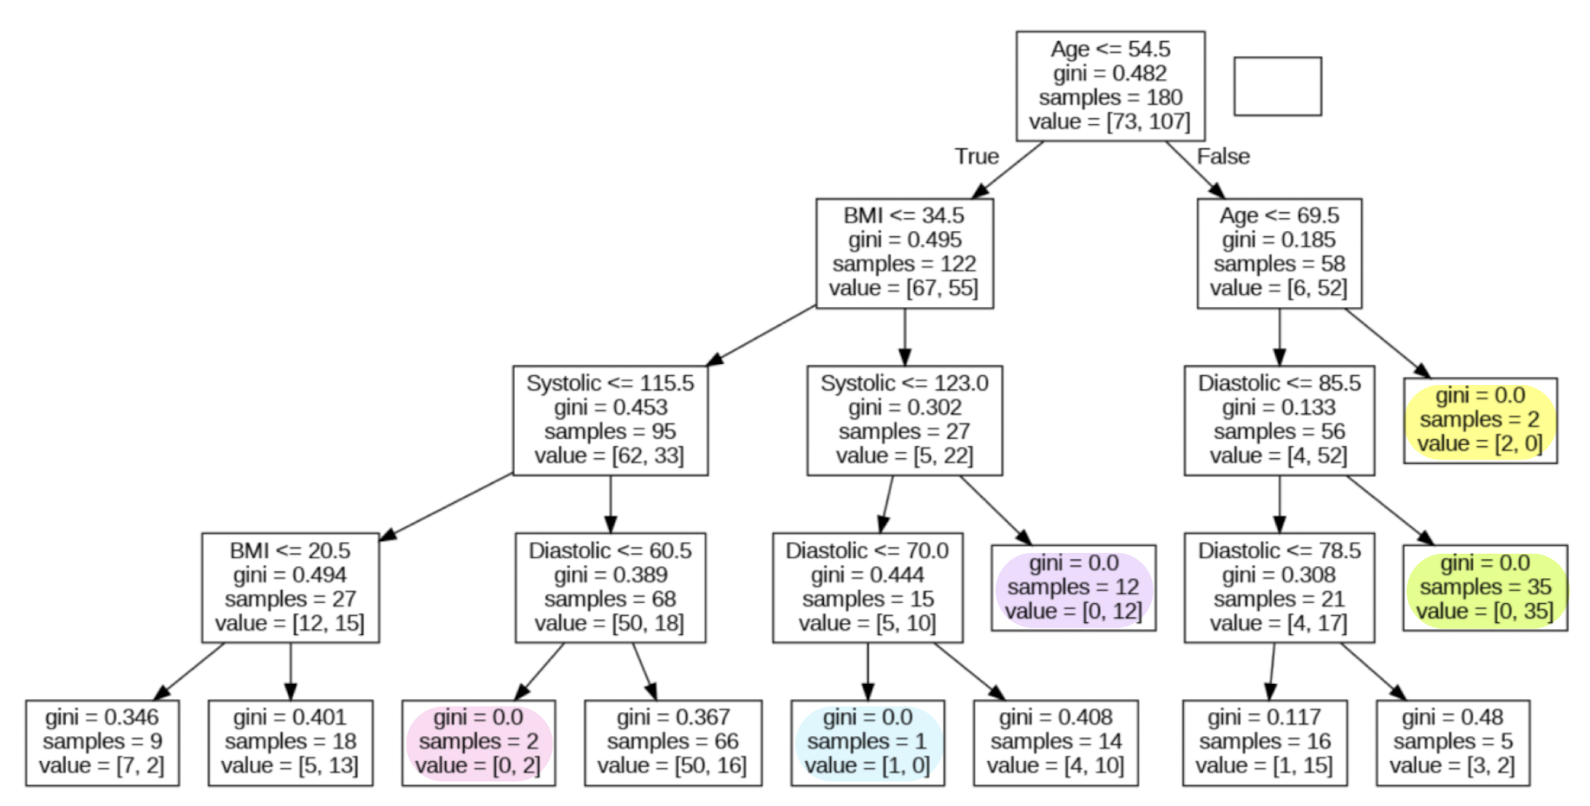


##**Análisis de resultados**
El árbol de decisión muestra una estructura lógica y coherente desde el punto de vista clínico. La variable que inicia la segmentación es la edad (Age), lo que indica que es el factor con mayor poder discriminante en el modelo. A partir de ahí, el árbol utiliza el BMI, la presión sistólica (systolic) y la presión diastólica (diastolic) para segmentar la clasificación, lo cual coincide con los principales factores de riesgo cardiovascular conocidos en la práctica médica.
El modelo logra identificar varios nodos puros, donde la clasificación es del 100% hacia una sola clase. Esto significa que existen combinaciones específicas de edad, presión arterial y BMI donde el riesgo es muy claro. Estos son:


**Regla de decisión nodo amarillo [2,0]**

IF Age > 54.5

AND Age > 69.5

THEN sin enfermedad / con enfermedad → Total datos: 2

-> Sin enfermedad = 2

-> Con enfermedad = 0

2/2 = 100% sin enfermedad (Significa que las personas con esas características, dentro de los datos, fueron todas clasificadas sin enfermedad cardíaca)

0/2 = 0% con enfermedad

---
**Regla de decisión nodo morado [0,12]**

IF Age ≤ 54.5

AND BMI > 34.5

AND Systolic > 123.0

THEN sin enfermedad / con enfermedad → Total datos: 12

-> Sin enfermedad = 0

-> Con enfermedad = 12

12/12 = 100% con enfermedad (Indica que todas las personas con esas condiciones, en los datos analizados, se clasifican en el grupo de enfermedad cardíaca. El grupo es completamente homogéneo)

0/12 = 0% sin enfermedad

---
**Regla de decisión nodo verde [0,35]**

IF Age > 54.5

AND Age ≤ 69.5

AND Diastolic > 85.5

THEN sin enfermedad / con enfermedad → Total datos: 35

-> Sin enfermedad = 0

-> Con enfermedad = 35

35/35 = 100% con enfermedad (Muestra que, para ese perfil, todos los registros correspondieron a personas con enfermedad)

0/35 = 0% sin enfermedad

---
**Regla de decisión nodo rosado [0,2]**

IF Age ≤ 54.5

AND BMI ≤ 34.5

AND Systolic ≤ 115.5

AND Diastolic ≤ 60.5

THEN sin enfermedad / con enfermedad → Total datos: 2

→ Sin enfermedad = 0

→ Con enfermedad = 2

2/2 = 100% con enfermedad (En este grupo, todas las observaciones fueron de personas con enfermedad. No hubo variación dentro del nodo)

0/2 = 0% sin enfermedad

---
**Regla de decisión nodo azul [1,0]**

IF Age ≤ 54.5

AND BMI > 34.5

AND Systolic ≤ 123.0

AND Diastolic ≤ 70.0

THEN sin enfermedad / con enfermedad → Total datos: 1

→ Sin enfermedad = 1

→ Con enfermedad = 0

1/1 = 100% sin enfermedad (Aquí el único caso con esas características fue sin enfermedad, por lo que el nodo queda completamente definido por esa clase)

0/1 = 0% con enfermedad
